In [1]:
'''回归（regression）是能为一个或多个自变量与因变量之间关系建模的一类方法。 在自然科学和社会科学领域，回归经常用来表示输入和输出之间的关系。

在机器学习领域中的大多数任务通常都与预测（prediction）有关。 当我们想预测一个数值时，就会涉及到回归问题。 常见的例子包括：预测价格（房屋、股票等）、预测住院时间（针对住院病人等）、 预测需求（零售销量等）。 但不是所有的预测都是回归问题。'''

'回归（regression）是能为一个或多个自变量与因变量之间关系建模的一类方法。 在自然科学和社会科学领域，回归经常用来表示输入和输出之间的关系。\n\n在机器学习领域中的大多数任务通常都与预测（prediction）有关。 当我们想预测一个数值时，就会涉及到回归问题。 常见的例子包括：预测价格（房屋、股票等）、预测住院时间（针对住院病人等）、 预测需求（零售销量等）。 但不是所有的预测都是回归问题。'

In [2]:
# y = < w, x > + b
# 权重决定了每个特征对我们预测值的影响。 b称为偏置（bias）、偏移量（offset）或截距（intercept）。 偏置是指当所有特征都取值为0时，预测值应该为多少。

In [3]:
# 在开始寻找最好的模型参数（model parameters）和之前， 我们还需要两个东西： （1）一种模型质量的度量方式； （2）一种能够更新模型以提高模型预测质量的方法。
# 损失函数（loss function）能够量化目标的实际值与预测值之间的差距。 通常我们会选择非负数作为损失，且数值越小表示损失越小，完美预测时的损失为0。 回归问题中最常用的损失函数是平方误差函数。
# 线性回归是少有的具有显式解的问题，多数深度学习都是没有显性倒数的

In [2]:
%matplotlib inline  
import random
import torch
from d2l import torch as d2l

In [101]:
# 构造一个人造数据集，w=[2,-3.4]T, b=6.66
def synthetic_data(w,b,n): # 加上随机噪声
    x= torch.normal(0,1,(n,len(w)))
    y= torch.matmul(x,w) + b
    y+=torch.normal(0,0.015,y.shape)
    return x,y.reshape(-1,1)

In [102]:
w_gt=torch.tensor([2,-3.4])
b_gt=torch.tensor([6.66])


In [103]:
features , labels =synthetic_data(w_gt,b_gt,200000)

In [104]:
print(f'feature:{features[0]}, \n labels:{labels[0]}')

feature:tensor([-2.4302, -0.3121]), 
 labels:tensor([2.8657])


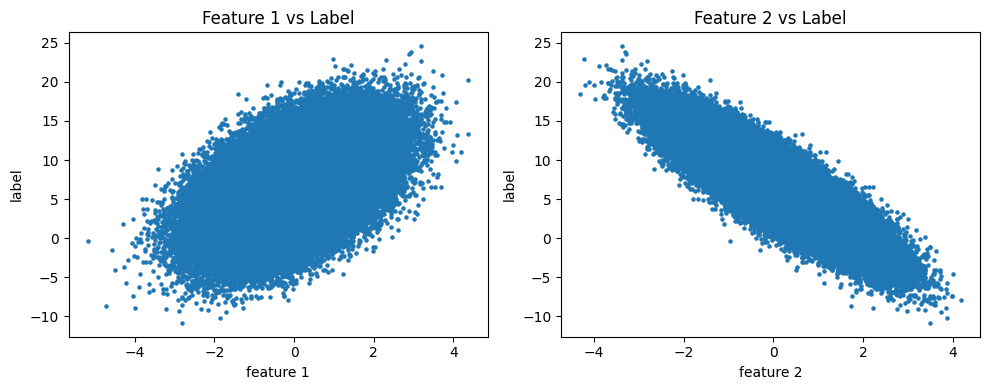

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

# 第一个特征与标签
plt.subplot(1, 2, 1)
plt.scatter(features[:, 0], labels, s=5)
plt.xlabel('feature 1')
plt.ylabel('label')
plt.title('Feature 1 vs Label')

# 第二个特征与标签
plt.subplot(1, 2, 2)
plt.scatter(features[:, 1], labels, s=5)
plt.xlabel('feature 2')
plt.ylabel('label')
plt.title('Feature 2 vs Label')

plt.tight_layout()
plt.show()

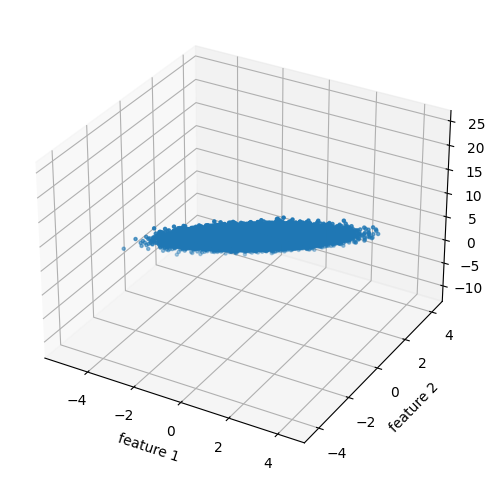

In [106]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    features[:, 0],
    features[:, 1],
    labels[:, 0],
    s=5
)

ax.set_xlabel('feature 1')
ax.set_ylabel('feature 2')
ax.set_zlabel('label')
plt.show()

In [107]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices) #随机打乱
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(
            indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
        #说明这是一个生成器函数。调用后不会一次性返回全部数据，而是每次产生一个小批次。

In [108]:
batch_size = 10

for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break

tensor([[-1.7264,  1.2428],
        [-1.9489,  0.8682],
        [-1.0096, -1.1381],
        [-0.5000,  0.2095],
        [-0.1423, -0.1126],
        [-1.4008, -0.8961],
        [-1.3708, -1.1536],
        [-0.9230,  1.3093],
        [ 1.2411, -0.3454],
        [ 0.7101,  1.8527]]) 
 tensor([[-1.0006],
        [-0.1680],
        [ 8.5408],
        [ 4.9526],
        [ 6.7700],
        [ 6.9139],
        [ 7.8306],
        [ 0.3631],
        [10.3367],
        [ 1.7798]])


(tensor([[-0.0015],
         [-0.0117]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [110]:
# 定义模型曲线
def linreg(X,w,b):
    return torch.matmul(X,w)+b

# 定义loss
def squared_loss(y_hat,y_gt):
    return (1/2)*((y_hat-y_gt.reshape(y_hat.shape))**2)



In [111]:
# 优化算法，调用这个函数更新param
def sgd(params, lr, batch_size):
    with torch.no_grad(): #这一步本身不是模型计算，而是优化器修改参数。因此必须用这一行，避免优化过程加到param的计算图里面。
        for param in params:
            param-=lr*param.grad/batch_size
            param.grad.zero_()
'''分成两部分
requires_grad=True：请帮我记录模型计算，以便之后求导
with torch.no_grad()：下面是修改参数的操作，不要记录这部分

w = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

y_hat = linreg(X, w, b)
loss = squared_loss(y_hat, y)

loss.sum().backward()

with torch.no_grad():
    w -= lr * w.grad / batch_size
    b -= lr * b.grad / batch_size

w.grad.zero_()
b.grad.zero_()
'''
#也就是说，with no\_grad是一小块临时区域，在这个区域里面的不要记录计算图，确保真正记录到计算图里面的是模型的计算过程         

'分成两部分\nrequires_grad=True：请帮我记录模型计算，以便之后求导\nwith torch.no_grad()：下面是修改参数的操作，不要记录这部分\n\nw = torch.normal(0, 0.01, size=(2, 1), requires_grad=True)\nb = torch.zeros(1, requires_grad=True)\n\ny_hat = linreg(X, w, b)\nloss = squared_loss(y_hat, y)\n\nloss.sum().backward()\n\nwith torch.no_grad():\n    w -= lr * w.grad / batch_size\n    b -= lr * b.grad / batch_size\n\nw.grad.zero_()\nb.grad.zero_()\n'

In [118]:
# 训练过程
lr = 0.03 #lr：学习率，控制参数每次更新的幅度
num_epochs = 10 #num_epochs：完整遍历数据集的次数
net = linreg #net = linreg：指定模型
loss = squared_loss #loss = squared_loss：指定损失函数
batch_size=50
for epoch in range(num_epochs): #这里会训练 3 轮。每一轮都会把全部 2000 个样本使用一次。
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y)  # X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，
        # 并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size)  # 使用参数的梯度更新参数
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')

epoch 1, loss 0.000112
epoch 2, loss 0.000112
epoch 3, loss 0.000112
epoch 4, loss 0.000113
epoch 5, loss 0.000112
epoch 6, loss 0.000112
epoch 7, loss 0.000112
epoch 8, loss 0.000112
epoch 9, loss 0.000112
epoch 10, loss 0.000112


In [116]:
print(f'学习结果w={w}, \n真值w_gt={w_gt}')
print(f'学习结果b={b}, \n真值b_gt={b_gt}')

学习结果w=tensor([[ 1.9998],
        [-3.3995]], requires_grad=True), 
真值w_gt=tensor([ 2.0000, -3.4000])
学习结果b=tensor([6.6599], requires_grad=True), 
真值b_gt=tensor([6.6600])
